A-B

In [22]:
import festim as F

model_barrier = F.HydrogenTransportProblemDiscontinuous()

thickness_a = 50e-6
thickness_b = 50e-6

mat_a = F.Material(
    D_0=1e-8,
    E_D=0.39,
    K_S_0=1e22,
    E_K_S=1.04,
)

mat_b = F.Material(
    D_0=4.1e-7,
    E_D=0.39,
    K_S_0=1.87e24,
    E_K_S=1.04,
)

volume_left = F.VolumeSubdomain1D(
    id=1, borders=[0, thickness_a], material=mat_a
)
volume_right = F.VolumeSubdomain1D(
    id=2, borders=[thickness_a, thickness_a + thickness_b], material=mat_b
)

boundary_left = F.SurfaceSubdomain1D(id=1, x=0)
boundary_right = F.SurfaceSubdomain1D(id=2, x=thickness_a + thickness_b)

model_barrier.subdomains = [
    volume_left,
    volume_right,
    boundary_left,
    boundary_right,
]

model_barrier.surface_to_volume = {
    boundary_left: volume_left,
    boundary_right: volume_right,
}
model_barrier.InterfaceMethod = "penalty"

model_barrier.interfaces = [
    F.Interface(id=3, subdomains=[volume_left, volume_right], penalty_term=1e12),
]

H = F.Species("H", subdomains=model_barrier.volume_subdomains)
model_barrier.species = [H]

import numpy as np

vertices_left = np.linspace(0, thickness_a, num=50)
vertices_right = np.linspace(thickness_a, thickness_a + thickness_b, num=50)
vertices = np.concatenate([vertices_left, vertices_right])

model_barrier.mesh = F.Mesh1D(vertices)
model_barrier.temperature = 600

left_bc = F.SievertsBC(
    subdomain=boundary_left, S_0=mat_a.K_S_0, E_S=mat_a.E_K_S, pressure=100, species=H
)

right_bc = F.FixedConcentrationBC(species=H, subdomain=boundary_right, value=0)
model_barrier.boundary_conditions = [left_bc, right_bc]

permeation_flux_ab= F.SurfaceFlux(field=H, surface=boundary_right)
vtx_exports = [
    F.VTXSpeciesExport(filename=f"h_{i}.bp", field=H, subdomain=vol) for i, vol in enumerate(model_barrier.volume_subdomains)
]

profile_exports = [
    F.Profile1DExport(field=spe, subdomain=vol)
    for spe in model_barrier.species
    for vol in model_barrier.volume_subdomains
]
model_barrier.exports = [permeation_flux_ab] + vtx_exports + profile_exports

model_barrier.settings = F.Settings(
    atol=1e0,
    rtol=1e-09,
    transient=False,
)

model_barrier.initialise()
model_barrier.run()

print(permeation_flux_ab.data)

[19475953.54481207]


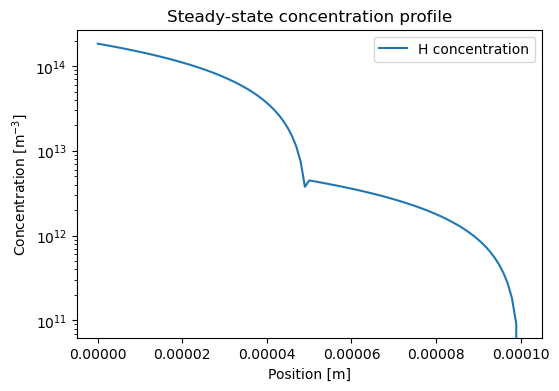

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Mesh coordinates
x = model_barrier.mesh.mesh.geometry.x[:, 0]

# Collect concentrations for each subdomain
data = []
for prof in profile_exports:
    data.append(prof.data[0])  # take steady-state solution

# Concatenate, but drop duplicate interface points
data = np.concatenate([d[:-1] for d in data[:-1]] + [data[-1]])

# Plot
plt.figure(figsize=(6,4))
plt.plot(x, data, label="H concentration")
plt.yscale("log")
plt.xlabel("Position [m]")
plt.ylabel("Concentration [m$^{-3}$]")
plt.title("Steady-state concentration profile")
plt.legend()
plt.show()


ABAB

In [37]:
import festim as F

model_barrier = F.HydrogenTransportProblemDiscontinuous()

thickness_a = 25e-6
thickness_b = 25e-6

mat_a = F.Material(
    D_0=1e-8,
    E_D=0.39,
    K_S_0=1e22,
    E_K_S=1.04,
)

mat_b = F.Material(
    D_0=4.1e-7,
    E_D=0.39,
    K_S_0=1.87e24,
    E_K_S=1.04,
)

volume_a_left = F.VolumeSubdomain1D(
    id=1, borders=[0, thickness_a], material=mat_a
)
volume_b_left = F.VolumeSubdomain1D(
    id=2, borders=[thickness_a, thickness_a + thickness_b], material=mat_b
)

volume_a_right = F.VolumeSubdomain1D(
    id=3, borders=[thickness_a+thickness_b, 2*thickness_a + thickness_b], material=mat_a
)

volume_b_right = F.VolumeSubdomain1D(
    id=4, borders=[2*thickness_a + thickness_b, 2*(thickness_a + thickness_b)], material=mat_b
)

boundary_left = F.SurfaceSubdomain1D(id=1, x=0)
boundary_right = F.SurfaceSubdomain1D(id=2, x=2*(thickness_a + thickness_b))

model_barrier.subdomains = [
    volume_a_left,
    volume_b_left,
    volume_a_right,
    volume_b_right,
    boundary_left,
    boundary_right,
]

model_barrier.surface_to_volume = {
    boundary_left: volume_a_left,
    boundary_right: volume_b_right,
}

model_barrier.InterfaceMethod = "nitsche"
model_barrier.interfaces = [
    F.Interface(id=3, subdomains=[volume_a_left, volume_b_left]),
    F.Interface(id=4, subdomains=[volume_b_left, volume_a_right]),
    F.Interface(id=5, subdomains=[volume_a_right, volume_b_right]),
]

H = F.Species("H", subdomains=model_barrier.volume_subdomains)
model_barrier.species = [H]

import numpy as np

vertices_a_left = np.linspace(0, thickness_a, num=2000)
vertices_b_left = np.linspace(thickness_a, thickness_a + thickness_b, num=2000)
vertices_a_right = np.linspace(thickness_a+thickness_b, 2*thickness_a + thickness_b, num=2000)
vertices_b_right = np.linspace(2*thickness_a+thickness_b, 2*(thickness_a + thickness_b), num=2000)

vertices = np.concatenate([vertices_a_left, vertices_b_left, vertices_a_right, vertices_b_right])

model_barrier.mesh = F.Mesh1D(vertices)

model_barrier.temperature = 600

left_bc = F.SievertsBC(
    subdomain=boundary_left, S_0=mat_a.K_S_0, E_S=mat_a.E_K_S, pressure=100, species=H
)
right_bc = F.FixedConcentrationBC(species=H, subdomain=boundary_right, value=0)

model_barrier.boundary_conditions = [left_bc, right_bc]

permeation_flux_abab = F.SurfaceFlux(field=H, surface=boundary_right)

vtx_exports = [
    F.VTXSpeciesExport(filename=f"h_{i}.bp", field=H, subdomain=vol) for i, vol in enumerate(model_barrier.volume_subdomains)
]

profile_exports = [
    F.Profile1DExport(field=spe, subdomain=vol)
    for spe in model_barrier.species
    for vol in model_barrier.volume_subdomains
]
model_barrier.exports = [permeation_flux_abab] + vtx_exports + profile_exports

model_barrier.settings = F.Settings(
    atol=1e-09,
    rtol=1e-09,
    transient=False,
)

model_barrier.initialise()
model_barrier.run()

print(permeation_flux_abab.data)

RuntimeError: Newton solver did not converge because maximum number of iterations reached

In [38]:
print(vertices)

[0.00000000e+00 1.25062531e-08 2.50125063e-08 ... 9.99749875e-05
 9.99874937e-05 1.00000000e-04]


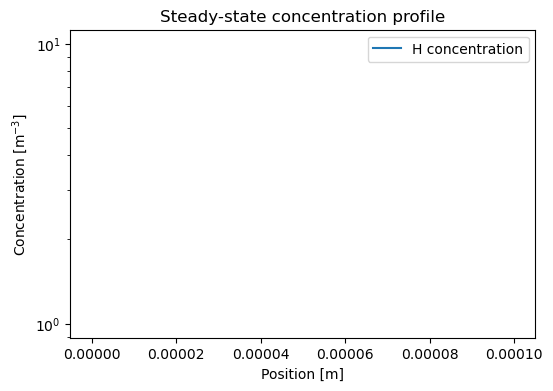

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Mesh coordinates
x = model_barrier.mesh.mesh.geometry.x[:, 0]

# Collect concentrations for each subdomain
data = []
for prof in profile_exports:
    data.append(prof.data[0])  # take steady-state solution

# Concatenate, but drop duplicate interface points
data = np.concatenate([d[:-1] for d in data[:-1]] + [data[-1]])

# Plot
plt.figure(figsize=(6,4))
plt.plot(x, data, label="H concentration")
plt.yscale("log")
plt.xlabel("Position [m]")
plt.ylabel("Concentration [m$^{-3}$]")
plt.title("Steady-state concentration profile")
plt.legend()
plt.show()


In [5]:
import numpy as np

permeation_difference = np.array(permeation_flux_abab.data) - np.array(permeation_flux_ab.data)
print("Difference in permeation flux between A-B and A-B-A-B:", permeation_difference)

Difference in permeation flux between A-B and A-B-A-B: [75.88851351]
